Computing entropy for isothermal lines...
Number of Dv points: 493
Number of isotherms: 20
Temperature range: 0.005 to 0.3 K
  Computing isotherm T = 0.005 K (1/20)
  Computing isotherm T = 0.083 K (6/20)
  Computing isotherm T = 0.160 K (11/20)
  Computing isotherm T = 0.238 K (16/20)


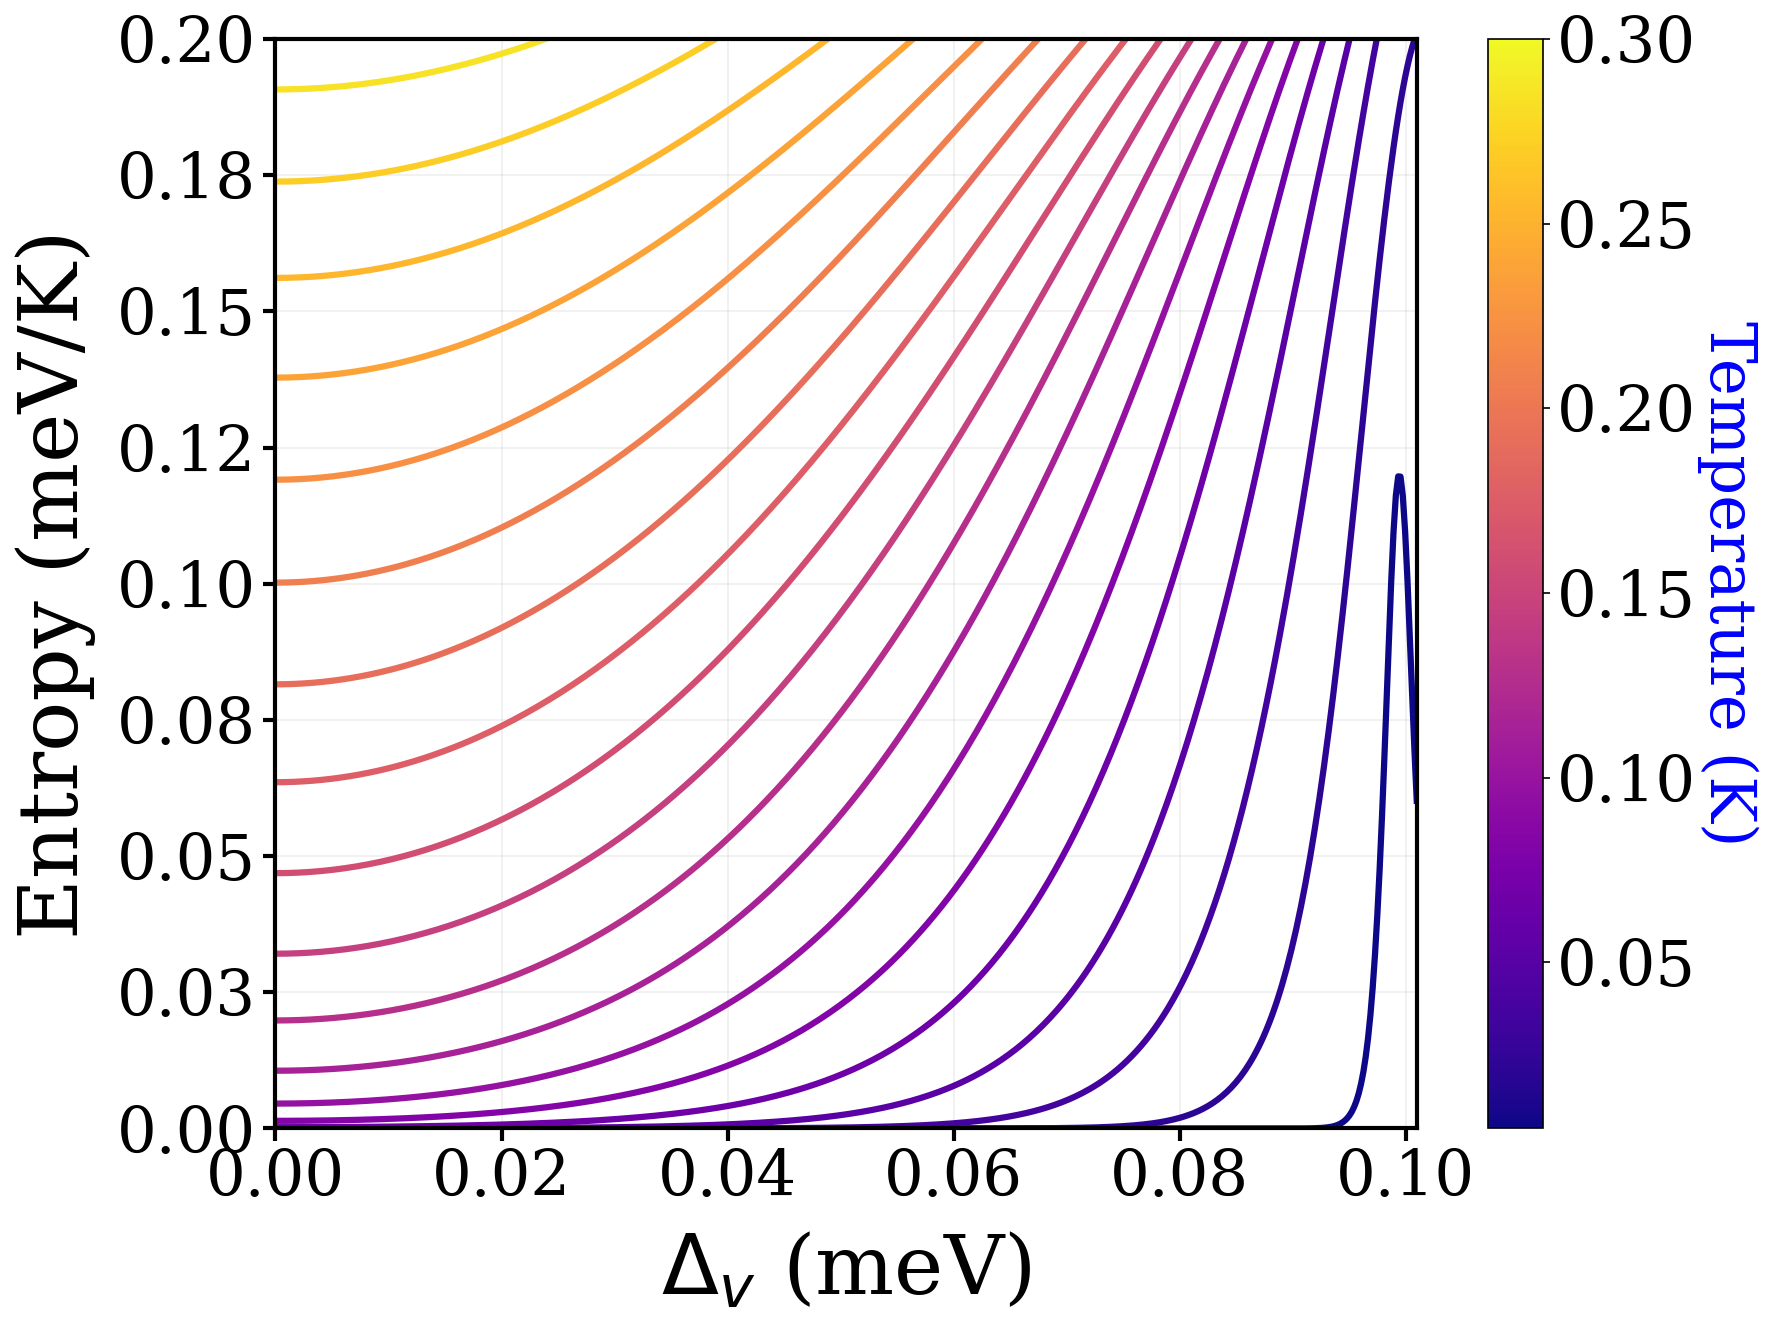

In [13]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as colors
from matplotlib.ticker import StrMethodFormatter

kb = 8.617333e-2  # meV/K

def free_energy(energies, T):
    """
    Free energy: F = -kbT * sum_n ln(1 + exp(-E_n/kbT))
    """
    kbT = kb * T
    # Stable calculation of ln(1 + exp(-x))
    x = energies / kbT
    log_term = np.where(x >= 0,
                        np.log1p(np.exp(-x)),
                        -x + np.log1p(np.exp(x)))
    return -kbT * np.sum(log_term)

def entropy_fd(energies, T, dT=1e-6):
    """
    S = -dF/dT
    Calculate entropy from free energy using central finite difference
    """
    F_plus = free_energy(energies, T + dT)
    F_minus = free_energy(energies, T - dT)
    return -(F_plus - F_minus) / (2 * dT)

data = np.loadtxt('ABS_MATBG_phi0_tillDv0205.dat', skiprows=1)
Dv_vals_all = data[:, 0]
spectra_all = data[:, 1:9]  # energies for each Dv value

# Filter to only Dv_vals <= 0.1
mask = Dv_vals_all <= 0.101
Dv_vals = Dv_vals_all[mask]
spectra = spectra_all[mask]

# Define temperature range for isothermal lines (from 0.001 to 0.3 K)
#T_selected = np.array([0.001, 0.005, 0.01, 0.02, 0.03, 0.05, 0.08, 0.10, 0.12, 0.15, 0.20, 0.25, 0.30])
T_selected = np.linspace(0.005, 0.3, 20)
num_T_lines = len(T_selected)

print("Computing entropy for isothermal lines...")
print(f"Number of Dv points: {len(Dv_vals)}")
print(f"Number of isotherms: {num_T_lines}")
print(f"Temperature range: {T_selected[0]} to {T_selected[-1]} K")

# Compute entropy for each temperature and each Dv
S_vs_Dv = np.zeros((len(T_selected), len(Dv_vals)))

for i, T in enumerate(T_selected):
    if i % 5 == 0:
        print(f"  Computing isotherm T = {T:.3f} K ({i+1}/{num_T_lines})")
    for j, Dv in enumerate(Dv_vals):
        E = spectra[j]
        E = E[~np.isnan(E)]  # Remove any NaN values
        S_vs_Dv[i, j] = entropy_fd(E, T)

# Create the plot (Delta_v on x-axis, Entropy on y-axis)
plt.figure(figsize=(12, 9))
ax = plt.gca()

# Create colormap for temperature
norm_T = colors.Normalize(vmin=T_selected.min(), vmax=T_selected.max())
cmap_T = plt.colormaps['plasma']

# Plot each isothermal line
for i, T in enumerate(T_selected):
    ax.plot(Dv_vals, S_vs_Dv[i, :],
            color=cmap_T(norm_T(T)),
            linewidth=3,
            label=f'T = {T:.3f} K' if i % 2 == 0 else "")  # Only label every other to avoid clutter

# Add colorbar for temperature
sm_T = plt.cm.ScalarMappable(cmap=cmap_T, norm=norm_T)
sm_T.set_array(T_selected)

cbar = plt.colorbar(sm_T, ax=ax, format='%.2f')
cbar.set_label('Temperature (K)', rotation=270, labelpad=30, fontsize=30, color='blue')
cbar.ax.tick_params(labelsize=30)

# Labels and formatting
ax.set_xlabel(r'$\Delta_v$ (meV)', fontsize=40, labelpad=10)
ax.set_ylabel('Entropy (meV/K)', fontsize=40, labelpad=10)
ax.tick_params(axis='both', which='major', labelsize=30, width=2, length=6)
ax.tick_params(axis='both', which='minor', labelsize=30, width=1, length=4)
ax.grid(True, alpha=0.2)

# Set axis limits
ax.set_xlim(Dv_vals.min(), Dv_vals.max())
ax.set_ylim(0, 0.2)  # Uncomment to set entropy limits

# Format tick labels
ax.xaxis.set_major_formatter(StrMethodFormatter('{x:.2f}'))
ax.yaxis.set_major_formatter(StrMethodFormatter('{x:.2f}'))

# Set spines linewidth
for spine in ax.spines.values():
    spine.set_linewidth(2)

plt.tight_layout()
plt.show()


Filtered Dv range: 0.0000 to 0.0999 meV
Number of Dv points: 488

Computing entropy matrix...
Temperature points: 200
Dv points: 488
  Processing Dv = 0.0000 meV (1/488)
  Processing Dv = 0.0041 meV (21/488)
  Processing Dv = 0.0082 meV (41/488)
  Processing Dv = 0.0123 meV (61/488)
  Processing Dv = 0.0164 meV (81/488)
  Processing Dv = 0.0205 meV (101/488)
  Processing Dv = 0.0246 meV (121/488)
  Processing Dv = 0.0287 meV (141/488)
  Processing Dv = 0.0328 meV (161/488)
  Processing Dv = 0.0369 meV (181/488)
  Processing Dv = 0.0410 meV (201/488)
  Processing Dv = 0.0451 meV (221/488)
  Processing Dv = 0.0492 meV (241/488)
  Processing Dv = 0.0534 meV (261/488)
  Processing Dv = 0.0575 meV (281/488)
  Processing Dv = 0.0616 meV (301/488)
  Processing Dv = 0.0657 meV (321/488)
  Processing Dv = 0.0698 meV (341/488)
  Processing Dv = 0.0739 meV (361/488)
  Processing Dv = 0.0780 meV (381/488)
  Processing Dv = 0.0821 meV (401/488)
  Processing Dv = 0.0862 meV (421/488)
  Processing Dv

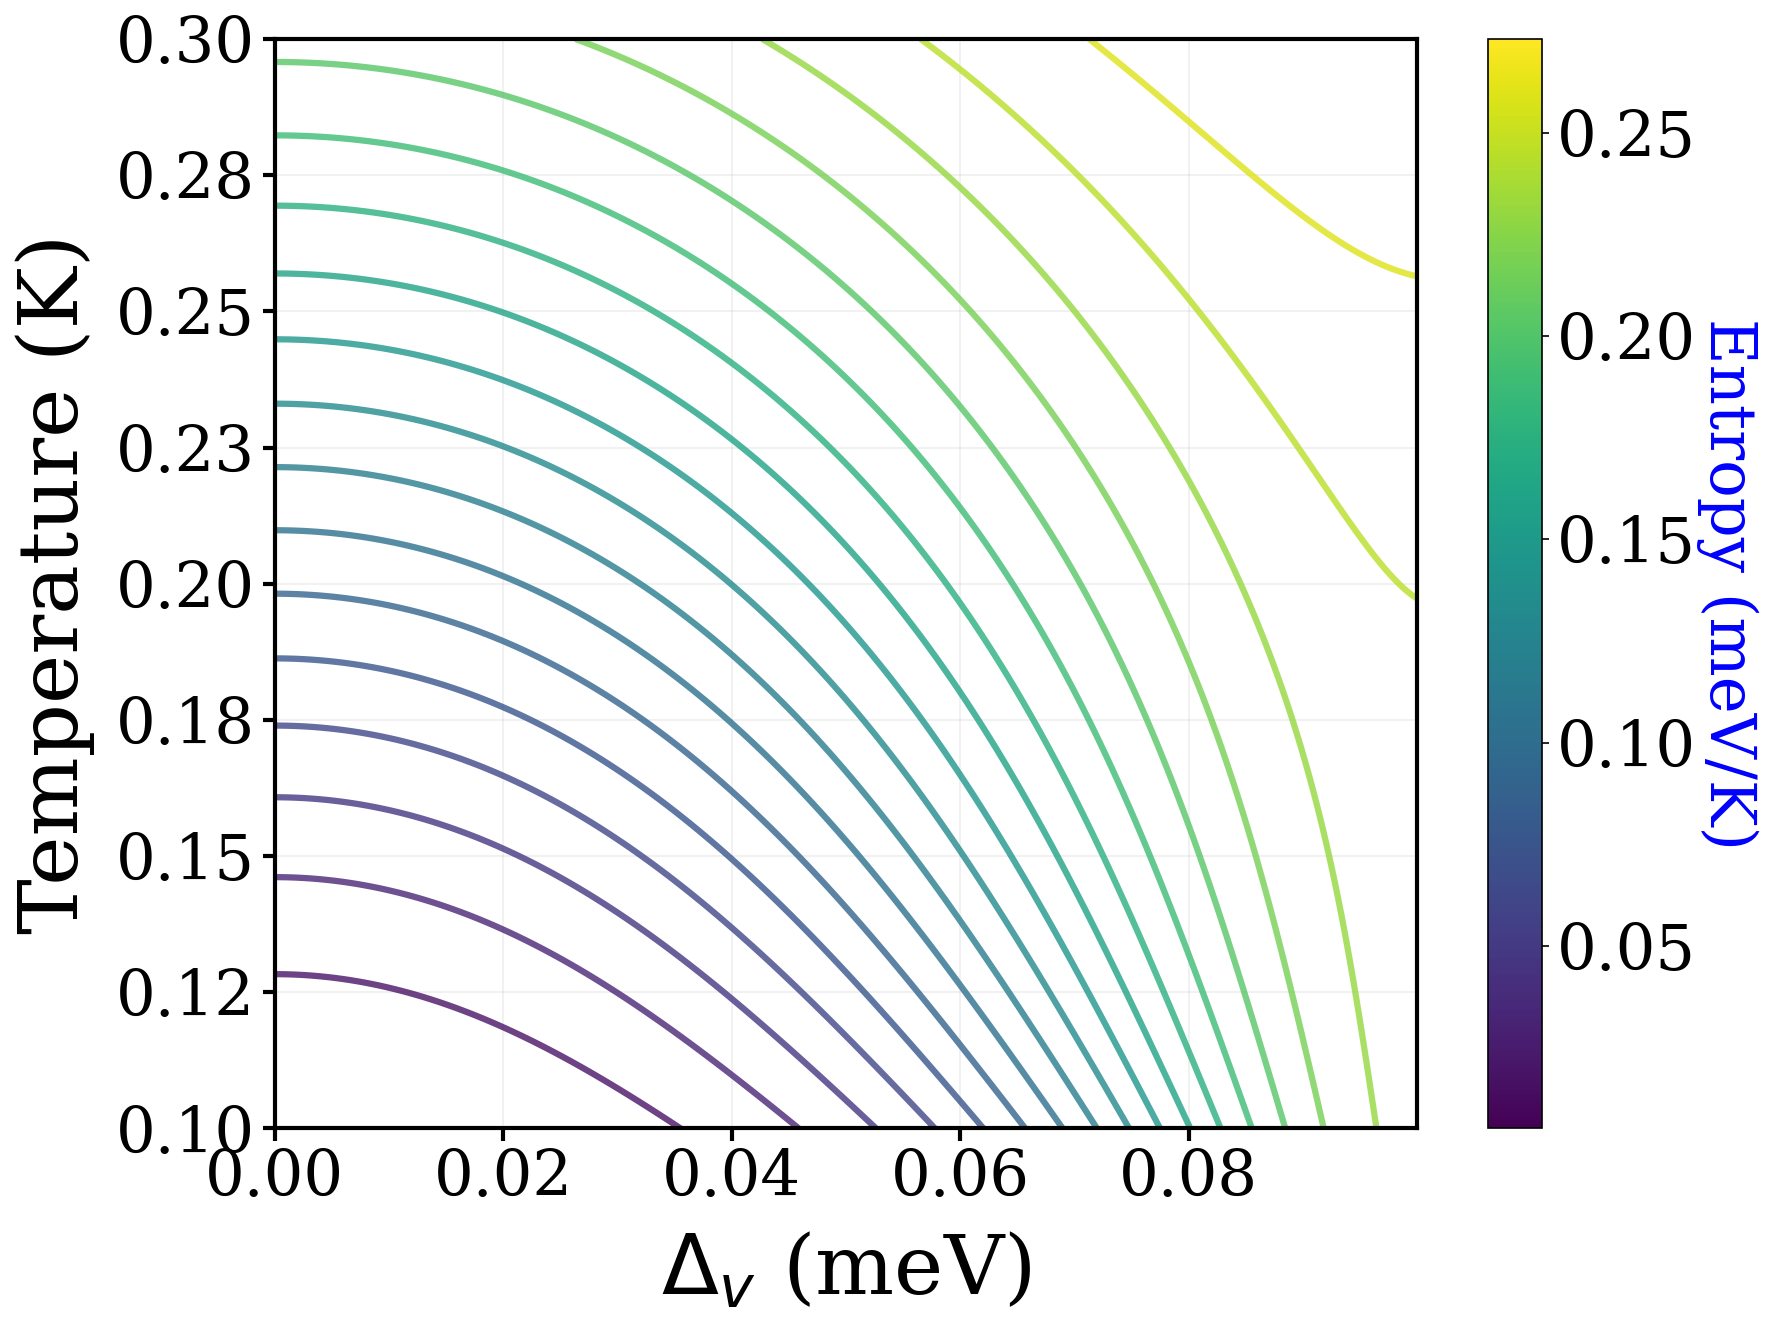

In [14]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as colors
from matplotlib.ticker import StrMethodFormatter

kb = 8.617333e-2  # meV/K

def free_energy(energies, T):
    """
    Free energy: F = -kbT * sum_n ln(1 + exp(-E_n/kbT))
    """
    kbT = kb * T
    # Stable calculation of ln(1 + exp(-x))
    x = energies / kbT
    log_term = np.where(x >= 0,
                        np.log1p(np.exp(-x)),
                        -x + np.log1p(np.exp(x)))
    return -kbT * np.sum(log_term)

def entropy_fd(energies, T, dT=1e-6):
    """
    S = -dF/dT
    Calculate entropy from free energy using central finite difference
    """
    F_plus = free_energy(energies, T + dT)
    F_minus = free_energy(energies, T - dT)
    return -(F_plus - F_minus) / (2 * dT)

# Load data
data = np.loadtxt('ABS_MATBG_phi0_tillDv0205.dat', skiprows=1)
Dv_vals_all = data[:, 0]
spectra_all = data[:, 1:9]  # energies for each Dv value

# Filter to only Dv_vals <= 0.1
mask = Dv_vals_all <= 0.1
Dv_vals = Dv_vals_all[mask]
spectra = spectra_all[mask]

print(f"Filtered Dv range: {Dv_vals.min():.4f} to {Dv_vals.max():.4f} meV")
print(f"Number of Dv points: {len(Dv_vals)}")

# Define temperature range
T_vals = np.linspace(0.1, 0.3, 200)  # Temperature from 0.001 to 0.3 K
n_T = len(T_vals)
n_Dv = len(Dv_vals)

print(f"\nComputing entropy matrix...")
print(f"Temperature points: {n_T}")
print(f"Dv points: {n_Dv}")

# Compute entropy for all Dv and T values
S_matrix = np.zeros((n_Dv, n_T))

for i, Dv in enumerate(Dv_vals):
    if i % 20 == 0:
        print(f"  Processing Dv = {Dv:.4f} meV ({i+1}/{n_Dv})")
    E = spectra[i]
    E = E[~np.isnan(E)]  # Remove any NaN values
    for j, T in enumerate(T_vals):
        S_matrix[i, j] = entropy_fd(E, T)

# Define entropy levels for isoentropic lines
S_min = np.nanmin(S_matrix)
S_max = np.nanmax(S_matrix)
print(f"\nEntropy range: {S_min:.6f} to {S_max:.6f} meV/K")

# Create evenly spaced entropy levels
num_levels = 20
S_levels = np.linspace(S_min, S_max, num_levels)

print(f"Creating {len(S_levels)} isoentropic lines")

# Create the plot (Delta_v on x-axis, Temperature on y-axis)
plt.figure(figsize=(12, 9))
ax = plt.gca()

# Create colormap for entropy
norm_S = colors.Normalize(vmin=S_min, vmax=S_max)
cmap_S = plt.colormaps['viridis']

# Plot isoentropic contours (without labels)
contour = ax.contour(Dv_vals, T_vals, S_matrix.T,  # Note: .T because contour expects (y, x)
                      levels=S_levels,
                      cmap=cmap_S,
                      linewidths=3,
                      alpha=0.8)

# Do NOT add labels to contours (clabel line is removed)

# Add colorbar for entropy
sm_S = plt.cm.ScalarMappable(cmap=cmap_S, norm=norm_S)
sm_S.set_array(S_matrix)
cbar = plt.colorbar(sm_S, ax=ax, format='%.2f')
cbar.set_label('Entropy (meV/K)', rotation=270, labelpad=30, fontsize=30, color='blue')
cbar.ax.tick_params(labelsize=30)

# Labels and formatting
ax.set_xlabel(r'$\Delta_v$ (meV)', fontsize=40, labelpad=10)
ax.set_ylabel('Temperature (K)', fontsize=40, labelpad=10)
ax.tick_params(axis='both', which='major', labelsize=30, width=2, length=6)
ax.tick_params(axis='both', which='minor', labelsize=30, width=1, length=4)
ax.grid(True, alpha=0.2)

# Set axis limits
ax.set_xlim(Dv_vals.min(), Dv_vals.max())
ax.set_ylim(T_vals.min(), T_vals.max())

# Format tick labels
ax.xaxis.set_major_formatter(StrMethodFormatter('{x:.2f}'))
ax.yaxis.set_major_formatter(StrMethodFormatter('{x:.2f}'))

# Set spines linewidth
for spine in ax.spines.values():
    spine.set_linewidth(2)

plt.tight_layout()
plt.show()


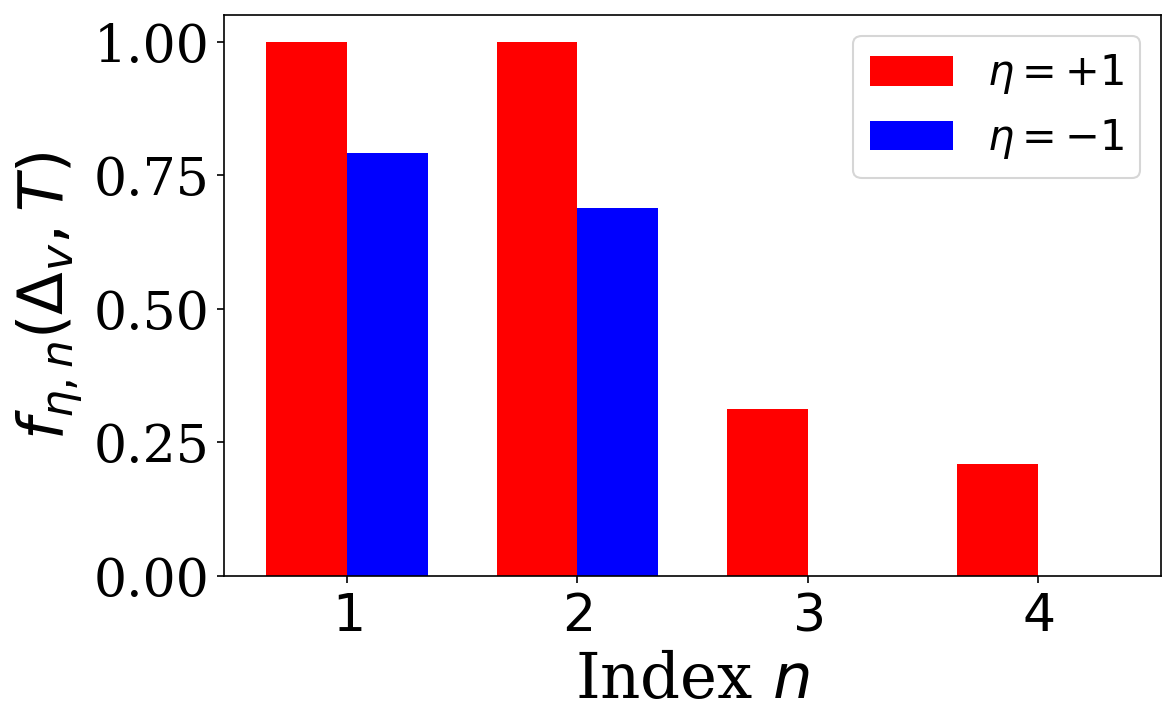

In [12]:
import numpy as np
import matplotlib.pyplot as plt

# Load data
data = np.loadtxt('ABS_MATBG_phi0_tillDv0205.dat', skiprows=1)

Dv = data[:,0]
energies = data[:,1:9]

kB = 8.617333262e-2

def fermi_dirac(E,T):
    # blue group
    E_blue = np.array([E[i] for i in [4,5,6,7]])
    # red group
    E_red  = np.array([E[i] for i in [0,1,2,3]])
    FD_blue = 1/(np.exp(E_blue/(kB*T))+1)
    FD_red  = 1/(np.exp(E_red /(kB*T))+1)
    return FD_blue,FD_red


# Choose Δv
Dv_target = 2.2*0.1032/2
T = 0.075
idx = np.argmin(np.abs(Dv-Dv_target))
E = energies[idx]
FD_blue,FD_red = fermi_dirac(E,T)
plt.figure(figsize=(8,5))
x = np.arange(4)
w = 0.35

plt.bar(x-w/2,FD_red,width=w,color='red',label=r'$\eta=+1$')
plt.bar(x+w/2,FD_blue,width=w,color='blue',label=r'$\eta=-1$')
plt.xticks(x,[r"$1$",r"$2$",r"$3$",r"$4$"])
plt.xlabel("Index $n$",fontsize=30)
plt.ylabel(r"$f_{\eta,n}(\Delta_{v},T)$",fontsize=30)
plt.tick_params(axis='both',which='major',labelsize=25)
plt.legend(fontsize=20)
plt.tight_layout()
plt.show()

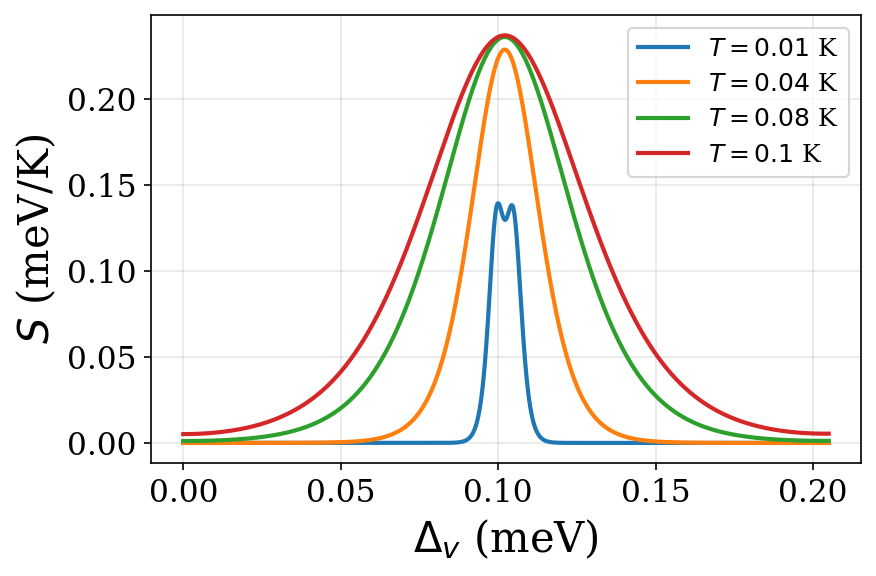

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# ── Load data ─────────────────────────────────────
data=np.loadtxt('ABS_MATBG_phi0_tillDv0205.dat',skiprows=1)

Dv=data[:,0]
energies=data[:,1:9]


# ── Constants ─────────────────────────────────────
kB=8.617333262e-2   # meV/K
Ts=[0.01,0.04,0.08,0.1]


# ── Entropy only ──────────────────────────────────
def compute_entropy(T):
    beta=1/(kB*T)
    arg=np.clip(-beta*energies,-500,500)
    F=-kB*T*np.sum(np.log1p(np.exp(arg)),axis=1)
    f=1/(np.exp(np.clip(beta*energies,-500,500))+1)
    U=np.sum(energies*f,axis=1)
    S=(U-F)/T

    return S


# ── Figure settings ───────────────────────────────
plt.rcParams.update({
    'font.family':'serif',
    'font.size':12,
    'axes.labelsize':14,
    'axes.titlesize':14,
    'figure.dpi':150
})

fig,ax=plt.subplots(figsize=(6,4))

# ── Plot entropy ──────────────────────────────────
for T in Ts:
    S=compute_entropy(T)
    ax.plot(Dv,S,lw=2,label=fr"$T={T}$ K")

ax.set_xlabel(r'$\Delta_v$ (meV)', fontsize = 20)
ax.set_ylabel(r'$S$ (meV/K)', fontsize = 20)
ax.tick_params(axis='both', labelsize=15)
ax.grid(alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

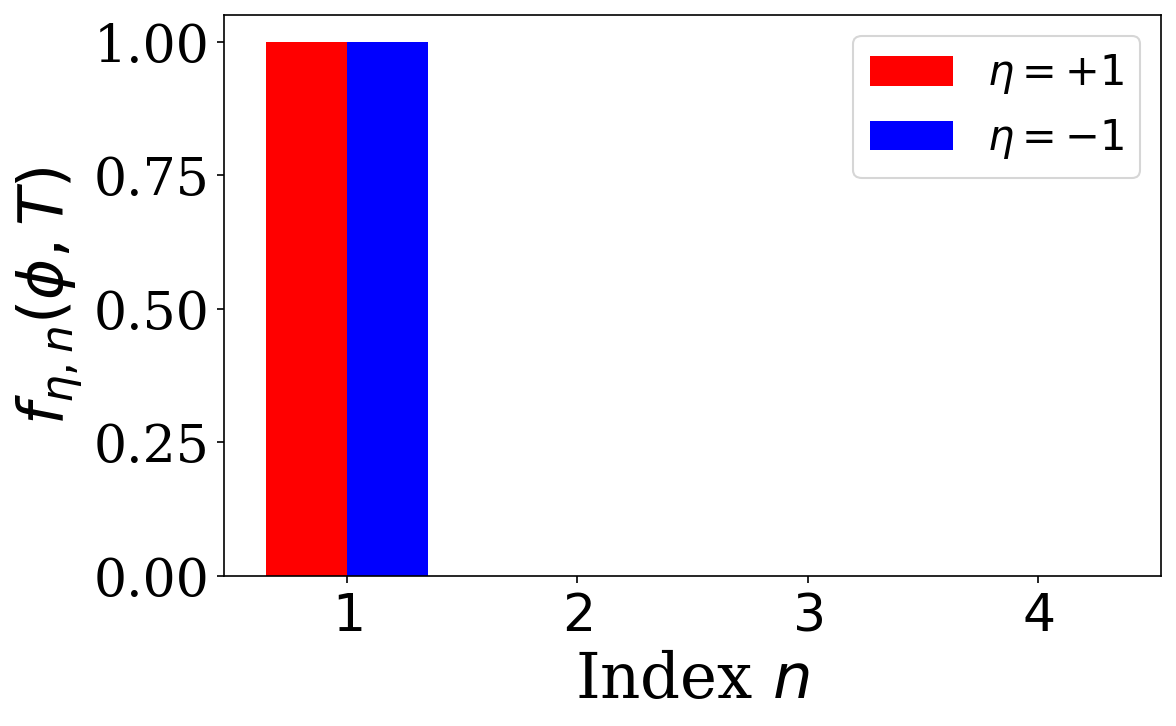

In [10]:
import numpy as np
import matplotlib.pyplot as plt

data_p = np.loadtxt("ABS_AABLG_taup_Dv0000_NEW.dat")
data_m = np.loadtxt("ABS_AABLG_taum_Dv0000_NEW.dat")

#data_p = np.loadtxt("ABS_MATBG_taup_Dv00.dat")
#data_m = np.loadtxt("ABS_MATBG_taum_Dv00.dat")

phi = np.pi/2
T = 0.075

phi_arr = data_p[:,0]
idx = np.argmin(np.abs(phi_arr-phi))

# τ=+1
E_p = data_p[idx,1:]
E_p = E_p[~np.isnan(E_p)]

# τ=-1
E_m = data_m[idx,1:]
E_m = E_m[~np.isnan(E_m)]

kB = 0.08617333

def fermi_dirac(E,T):
    return 1/(np.exp(E/(kB*T))+1)

FD_p = fermi_dirac(E_p,T)
FD_m = fermi_dirac(E_m,T)

# ---- force length = 4 ----
N = 4

FD_p_fixed = np.zeros(N)
FD_m_fixed = np.zeros(N)

FD_p_fixed[:min(len(FD_p),N)] = FD_p[:N]
FD_m_fixed[:min(len(FD_m),N)] = FD_m[:N]

x = np.arange(1,N+1)

plt.figure(figsize=(8,5))

w=0.35

plt.bar(x-w/2,FD_p_fixed,width=w,color='red',label=r'$\eta=+1$')
plt.bar(x+w/2,FD_m_fixed,width=w,color='blue',label=r'$\eta=-1$')
plt.xticks(x,[rf"${i}$" for i in x])
plt.xlabel("Index $n$",fontsize=30)
plt.ylabel(r"$f_{\eta,n}(\phi,T)$",fontsize=30)
plt.tick_params(axis='both',which='major',labelsize=25)
plt.legend(fontsize=20)
plt.tight_layout()
plt.show()

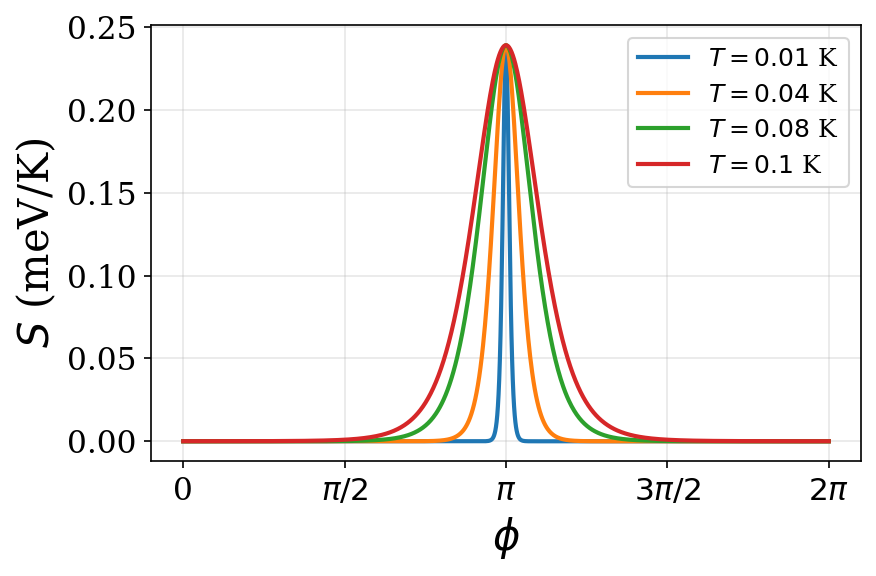

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter, MultipleLocator

# ── Load data ─────────────────────────────────────
data_p = np.loadtxt("ABS_AABLG_taup_Dv0000_NEW.dat")
data_m = np.loadtxt("ABS_AABLG_taum_Dv0000_NEW.dat")

#data_p = np.loadtxt("ABS_MATBG_taup_Dv00.dat")
#data_m = np.loadtxt("ABS_MATBG_taum_Dv00.dat")

phi_arr = data_p[:,0]

# ── Constants ─────────────────────────────────────
kB = 8.617333262e-2   # meV/K
Ts=[0.01,0.04,0.08,0.1]

# ── Build energy array ────────────────────────────
def build_energy_array(data_p,data_m):
    rows=[]
    for i in range(len(data_p)):
        ep=data_p[i,1:]
        ep=ep[~np.isnan(ep)]
        em=data_m[i,1:]
        em=em[~np.isnan(em)]
        rows.append(np.concatenate([ep,em]))
    max_len=max(len(r) for r in rows)
    arr=np.full((len(rows),max_len),np.nan)

    for i,r in enumerate(rows):
        arr[i,:len(r)] = r
    return arr


energies=build_energy_array(data_p,data_m)


# ── Entropy only ──────────────────────────────────
def compute_entropy(energies,T):
    beta=1/(kB*T)
    valid=~np.isnan(energies)
    arg=np.where(valid,np.clip(-beta*energies,-500,500),0)
    logterms=np.where(valid,np.log1p(np.exp(arg)),0)
    F=-kB*T*np.sum(logterms,axis=1)
    bE=np.where(valid,np.clip(beta*energies,-500,500),500)
    f=np.where(valid,1/(np.exp(bE)+1),0)
    U=np.sum(np.where(valid,energies*f,0),axis=1)
    S=(U-F)/T
    return S


# ── Plot settings ─────────────────────────────────
plt.rcParams.update({
    'font.family':'serif',
    'font.size':12,
    'axes.labelsize':14,
    'axes.titlesize':14,
    'figure.dpi':150
})

fig,ax=plt.subplots(figsize=(6,4))


for T in Ts:
    S=compute_entropy(energies,T)
    ax.plot(phi_arr,S,lw=2,label=fr"$T={T}$ K")


# ── π labels ──────────────────────────────────────
def pi_formatter(val,pos):
    frac=val/np.pi
    if np.isclose(frac,0):
        return '0'
    elif np.isclose(frac,0.5):
        return r'$\pi/2$'
    elif np.isclose(frac,1):
        return r'$\pi$'
    elif np.isclose(frac,1.5):
        return r'$3\pi/2$'
    elif np.isclose(frac,2):
        return r'$2\pi$'

    return ''


ax.xaxis.set_major_locator(MultipleLocator(np.pi/2))
ax.xaxis.set_major_formatter(FuncFormatter(pi_formatter))
ax.grid(alpha=0.3)
ax.set_xlabel(r'$\phi$', fontsize = 20)
ax.set_ylabel(r'$S$ (meV/K)', fontsize = 20)
ax.tick_params(axis='both', labelsize=15)
ax.legend()
plt.tight_layout()
plt.show()